# Game Recomendations on Steam Platform 

Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler

DataFiles

In [2]:
# Read the data from files
path = '/Users/manju/Desktop/Data'
df_games = pd.read_csv(path+"/games.csv")
df_users = pd.read_csv(path+"/users.csv")
df_recommendations = pd.read_csv(path+"/recommendations.csv")
df_genre = pd.read_json(path+'/games_metadata.json', lines=True)

Overview

In [3]:
df_games.head(10)

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
5,250180,METAL SLUG 3,2015-09-14,True,False,False,Very Positive,90,5579,7.99,7.99,0.0,True
6,253980,Enclave,2013-10-04,True,True,True,Mostly Positive,75,1608,4.99,4.99,0.0,True
7,271850,Men of War: Assault Squad 2 - Deluxe Edition u...,2014-05-16,True,False,False,Mixed,61,199,6.99,6.99,0.0,True
8,282900,Hyperdimension Neptunia Re;Birth1,2015-01-29,True,False,False,Very Positive,94,9686,14.99,14.99,0.0,True
9,19810,The Sum of All Fears,2008-10-10,True,False,False,Mostly Positive,75,33,9.99,9.99,0.0,True


In [4]:
df_users.head(10)

,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2
5,5664667,145,5
6,5889167,447,2
7,7281762,1083,1
8,7445952,273,1
9,7462927,51,1


In [5]:
df_recommendations.head(10)

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4
5,306130,0,0,2021-10-10,True,8.6,45425,5
6,238960,0,0,2017-11-25,True,538.8,88282,6
7,730,0,0,2021-11-30,False,157.5,63209,7
8,255710,0,0,2021-05-21,True,18.7,354512,8
9,289070,0,0,2020-05-26,True,397.5,454422,9


In [6]:
df_genre.head(10)

,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
5,250180,"“METAL SLUG 3”, the masterpiece in SNK’s emble...","[Arcade, Classic, Action, Co-op, Side Scroller..."
6,253980,Experience incredibly atmospheric and intense ...,"[RPG, Action, Fantasy, Third Person, Hack and ..."
7,271850,,"[Strategy, Simulation, Action, RTS, World War II]"
8,282900,"Packed with fast-paced, turn-based RPG action,...","[Anime, JRPG, Female Protagonist, Cute, RPG, S..."
9,19810,Lead a team of domestic counter-terrorism expe...,"[Action, Tactical]"


In [7]:
#Metadata of Dataframes
df_list = [
    ("df_games", df_games),
    ("df_users", df_users),
    ("df_recommendations", df_recommendations),
    ("df_genre", df_genre)
]

for name, df in df_list:
    print(f"\n📄 DataFrame: {name}")
    df.info()


📄 DataFrame: df_games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB

📄 DataFrame: df_users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14306064 entries, 0 to 14306063
Data columns (tot

In [8]:
# Converting all object columns to string dtype
df_games = df_games.astype({col: 'string' for col in df_games.select_dtypes(include='object').columns})
df_genre = df_genre.astype({col: 'string' for col in df_genre.select_dtypes(include='object').columns})

# Converting the date related columns to date dtype
df_games['date_release'] = pd.to_datetime(df_games['date_release'])
df_recommendations['date'] = pd.to_datetime(df_recommendations['date'])

In [9]:
#Metadata of Dataframes after datatype conversions
df_list = [
    ("df_games", df_games),
    ("df_users", df_users),
    ("df_recommendations", df_recommendations),
    ("df_genre", df_genre)
]

for name, df in df_list:
    print(f"\n📄 DataFrame: {name}")
    df.info()


📄 DataFrame: df_games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   app_id          50872 non-null  int64         
 1   title           50872 non-null  string        
 2   date_release    50872 non-null  datetime64[ns]
 3   win             50872 non-null  bool          
 4   mac             50872 non-null  bool          
 5   linux           50872 non-null  bool          
 6   rating          50872 non-null  string        
 7   positive_ratio  50872 non-null  int64         
 8   user_reviews    50872 non-null  int64         
 9   price_final     50872 non-null  float64       
 10  price_original  50872 non-null  float64       
 11  discount        50872 non-null  float64       
 12  steam_deck      50872 non-null  bool          
dtypes: bool(4), datetime64[ns](1), float64(3), int64(3), string(2)
memory usage: 3.7 MB

In [10]:
for name, df in df_list:
    print(f"Total No. of records in \n📄 DataFrame: {name}")
    print(df.shape[0])

Total No. of records in 
📄 DataFrame: df_games
50872
Total No. of records in 
📄 DataFrame: df_users
14306064
Total No. of records in 
📄 DataFrame: df_recommendations
41154794
Total No. of records in 
📄 DataFrame: df_genre
50872


In [11]:
#Checking for Null Values
for name, df in df_list:
    print(f"\n📄 DataFrame Null Values: {name}")
    print(df.isna().sum())


📄 DataFrame Null Values: df_games
app_id            0
title             0
date_release      0
win               0
mac               0
linux             0
rating            0
positive_ratio    0
user_reviews      0
price_final       0
price_original    0
discount          0
steam_deck        0
dtype: int64

📄 DataFrame Null Values: df_users
user_id     0
products    0
reviews     0
dtype: int64

📄 DataFrame Null Values: df_recommendations
app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
user_id           0
review_id         0
dtype: int64

📄 DataFrame Null Values: df_genre
app_id         0
description    0
tags           0
dtype: int64


In [12]:
#Checking for 'app_id' Duplicate Values in all dataframes
for name, df in df_list:
    if 'app_id' in df:
        print(f'Total records count in {name} 📄: ',df.shape[0])
        print(f'Distinct app_id records in {name} 📄: ',df['app_id'].nunique())
        
#Checking for 'user_id' Duplicate Values in df_users
print(f'Total records count in df_users 📄: ',df_users.shape[0])
print(f'Distinct user_id records in df_users 📄: ',df_users['user_id'].nunique()) 

#Checking for duplicated based on combination of app_id & their description
print(f'Total duplicate records count in df_games 📄: ',df_games.duplicated(subset=['app_id', 'title']).sum())
print(f'Total duplicate records count in df_genre 📄: ',df_genre.duplicated(subset=['app_id','description']).sum())     
        

Total records count in df_games 📄:  50872
Distinct app_id records in df_games 📄:  50872
Total records count in df_recommendations 📄:  41154794
Distinct app_id records in df_recommendations 📄:  37610
Total records count in df_genre 📄:  50872
Distinct app_id records in df_genre 📄:  50872
Total records count in df_users 📄:  14306064
Distinct user_id records in df_users 📄:  14306064
Total duplicate records count in df_games 📄:  0
Total duplicate records count in df_genre 📄:  0


Data Preprocessing

In [13]:
#Focusing only on the games available on macos
counts = df_games['mac'].value_counts()
print(counts)

mac
False    37854
True     13018
Name: count, dtype: int64


In [14]:
df_games_processed = df_games.copy()
df_games_processed = df_games_processed[df_games_processed['mac'] == True]

In [15]:
df_games_processed

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
6,253980,Enclave,2013-10-04,True,True,True,Mostly Positive,75,1608,4.99,4.99,0.0,True
13,29180,Osmos,2009-08-18,True,True,True,Very Positive,88,532,9.99,9.99,0.0,True
18,245950,Borderlands 2: Headhunter 4: Wedding Day Massacre,2014-02-11,True,True,True,Very Positive,84,294,0.89,2.99,70.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50830,2195430,Two Point Campus: Medical School,2023-08-17,True,True,True,Mixed,50,22,10.00,0.00,0.0,True
50835,2446110,Stacklands: Cursed Worlds,2023-07-25,True,True,False,Very Positive,90,62,4.00,0.00,0.0,True
50848,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,True,True,True,Mixed,67,80,5.00,0.00,0.0,True
50851,1555150,Pocket Bravery,2023-08-31,True,True,True,Very Positive,89,248,20.00,0.00,0.0,True


In [16]:
#Considering only the past 5 years games
df_games_sub = df_games_processed.copy()
df_games_sub['date'] = pd.to_datetime(df_games_sub['date_release'])
df_games_sub = df_games_sub[df_games_sub['date'].dt.year > 2019]

In [17]:
df_games_sub.drop(columns=['win', 'mac','linux','steam_deck','positive_ratio', 'discount', 'price_original', 'date'], inplace=True)

In [18]:

# Define custom order from worst to best (if reversed)
order = ["Overwhelmingly Positive", "Very Positive", "Positive", "Mostly Positive",
         "Mixed", "Mostly Negative", "Negative", "Very Negative", "Overwhelmingly Negative"][::-1]

# Initialize encoder with the custom order
enc = OrdinalEncoder(categories=[order])

# Transform the 'rating' column to ordinal values
df_games_sub[['rating']] = enc.fit_transform(df_games_sub[['rating']])

In [19]:
df_games_sub

,app_id,title,date_release,rating,user_reviews,price_final
32,1872790,Luckitown,2022-01-19,7.0,163,4.99
39,1259750,Tropico 6 - Spitter,2020-04-23,4.0,36,9.99
143,498310,RPG in a Box,2022-05-10,7.0,153,29.99
171,672630,Academia : School Simulator,2021-01-28,7.0,2170,19.99
253,914890,Nine Noir Lives,2022-09-07,6.0,39,19.99
...,...,...,...,...,...,...
50830,2195430,Two Point Campus: Medical School,2023-08-17,4.0,22,10.00
50835,2446110,Stacklands: Cursed Worlds,2023-07-25,7.0,62,4.00
50848,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,4.0,80,5.00
50851,1555150,Pocket Bravery,2023-08-31,7.0,248,20.00


In [20]:
# Choose the numeric columns to normalize
numeric_cols = ['rating', 'user_reviews', 'price_final']

# Fit scaler and transform
scaler = MinMaxScaler()
df_games_sub[numeric_cols] = scaler.fit_transform(df_games_sub[numeric_cols])

In [21]:
games_processed = pd.merge(df_games_sub, df_genre[['app_id', 'tags']], on='app_id', how='inner')

In [22]:
games_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4298 entries, 0 to 4297
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   app_id        4298 non-null   int64         
 1   title         4298 non-null   string        
 2   date_release  4298 non-null   datetime64[ns]
 3   rating        4298 non-null   float64       
 4   user_reviews  4298 non-null   float64       
 5   price_final   4298 non-null   float64       
 6   tags          4298 non-null   string        
dtypes: datetime64[ns](1), float64(3), int64(1), string(2)
memory usage: 235.2 KB


In [23]:
games_processed

,app_id,title,date_release,rating,user_reviews,price_final,tags
0,1872790,Luckitown,2022-01-19,0.875,0.000567,0.024951,"['Simulation', 'Tower Defense', 'Strategy', 'T..."
1,1259750,Tropico 6 - Spitter,2020-04-23,0.500,0.000096,0.049952,"['Simulation', 'Strategy']"
2,498310,RPG in a Box,2022-05-10,0.875,0.000530,0.149957,"['Game Development', 'Animation & Modeling', '..."
3,672630,Academia : School Simulator,2021-01-28,0.875,0.008005,0.099955,"['Management', 'City Builder', 'Base Building'..."
4,914890,Nine Noir Lives,2022-09-07,0.750,0.000107,0.099955,"['Point & Click', 'Comedy', '2D', 'Noir', 'Cut..."
...,...,...,...,...,...,...,...
4293,2195430,Two Point Campus: Medical School,2023-08-17,0.500,0.000044,0.050003,[]
4294,2446110,Stacklands: Cursed Worlds,2023-07-25,0.875,0.000193,0.020001,"['Simulation', 'Indie', 'Casual', 'Survival', ..."
4295,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,0.500,0.000259,0.025001,"['Strategy', 'Indie', 'Simulation']"
4296,1555150,Pocket Bravery,2023-08-31,0.875,0.000882,0.100005,[]


In [24]:
games_processed = (
    games_processed
      .dropna(subset=['tags'])                  # remove NaNs in tags
      [ games_processed['tags'].map(len) > 2 ]  # then remove empty lists
)

In [25]:
games_processed

,app_id,title,date_release,rating,user_reviews,price_final,tags
0,1872790,Luckitown,2022-01-19,0.875,0.000567,0.024951,"['Simulation', 'Tower Defense', 'Strategy', 'T..."
1,1259750,Tropico 6 - Spitter,2020-04-23,0.500,0.000096,0.049952,"['Simulation', 'Strategy']"
2,498310,RPG in a Box,2022-05-10,0.875,0.000530,0.149957,"['Game Development', 'Animation & Modeling', '..."
3,672630,Academia : School Simulator,2021-01-28,0.875,0.008005,0.099955,"['Management', 'City Builder', 'Base Building'..."
4,914890,Nine Noir Lives,2022-09-07,0.750,0.000107,0.099955,"['Point & Click', 'Comedy', '2D', 'Noir', 'Cut..."
...,...,...,...,...,...,...,...
4288,1410330,Love Shore,2023-06-30,0.500,0.000096,0.074954,"['Cyberpunk', 'RPG', 'Choices Matter', 'Noir',..."
4289,2159650,Drift,2023-05-12,0.500,0.000096,0.079954,"['Open World Survival Craft', 'Survival', 'Onl..."
4291,2349040,Dinky Guardians,2023-10-02,0.750,0.000022,0.065003,"['Automation', 'Simulation', 'Co-op', 'Colony ..."
4294,2446110,Stacklands: Cursed Worlds,2023-07-25,0.875,0.000193,0.020001,"['Simulation', 'Indie', 'Casual', 'Survival', ..."


In [26]:
common_game_ids = games_processed['app_id'].unique()
recommendations = df_recommendations[df_recommendations['app_id'].isin(common_game_ids)].copy()

In [27]:
recommendations.count()

app_id            1279263
helpful           1279263
funny             1279263
date              1279263
is_recommended    1279263
hours             1279263
user_id           1279263
review_id         1279263
dtype: int64

In [28]:
recommendations

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
73932,1218210,8,0,2022-07-13,True,119.5,4159892,73932
76525,1218210,6,0,2022-04-09,True,24.3,9824132,76525
132577,1218210,14,0,2022-04-01,True,11.7,11311605,132577
254185,1218210,2,0,2022-06-30,True,32.7,3830708,254185
300086,1218210,123,36,2022-04-04,False,32.5,11545696,300086
...,...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,True,3.0,9985656,41154745
41154746,893850,0,0,2020-09-14,True,128.0,821144,41154746
41154748,1404850,0,0,2021-04-15,True,8.0,11065427,41154748
41154769,1138660,0,0,2021-08-13,False,11.0,10433531,41154769


In [29]:
#Droping the review_id column & coverting booolean to numeric
recommendations.drop(columns=['review_id'], inplace=True)
recommendations['is_recommended'] = recommendations['is_recommended'].astype(int)

In [30]:
recommendations

,app_id,helpful,funny,date,is_recommended,hours,user_id
73932,1218210,8,0,2022-07-13,1,119.5,4159892
76525,1218210,6,0,2022-04-09,1,24.3,9824132
132577,1218210,14,0,2022-04-01,1,11.7,11311605
254185,1218210,2,0,2022-06-30,1,32.7,3830708
300086,1218210,123,36,2022-04-04,0,32.5,11545696
...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,1,3.0,9985656
41154746,893850,0,0,2020-09-14,1,128.0,821144
41154748,1404850,0,0,2021-04-15,1,8.0,11065427
41154769,1138660,0,0,2021-08-13,0,11.0,10433531


In [31]:
count = (recommendations['hours'] < 2).sum()
count

np.int64(222962)

In [32]:
recommendations_df = recommendations[recommendations['hours'] > 2].copy()

In [33]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id
73932,1218210,8,0,2022-07-13,1,119.5,4159892
76525,1218210,6,0,2022-04-09,1,24.3,9824132
132577,1218210,14,0,2022-04-01,1,11.7,11311605
254185,1218210,2,0,2022-06-30,1,32.7,3830708
300086,1218210,123,36,2022-04-04,0,32.5,11545696
...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,1,3.0,9985656
41154746,893850,0,0,2020-09-14,1,128.0,821144
41154748,1404850,0,0,2021-04-15,1,8.0,11065427
41154769,1138660,0,0,2021-08-13,0,11.0,10433531


In [34]:
#Compute max hours_played per user
user_max_hours = recommendations_df.groupby('user_id')['hours'].max().reset_index()
user_max_hours.rename(columns={'hours': 'max_hours'}, inplace=True)

# Merge with original DataFrame
recommendations_df = recommendations_df.merge(user_max_hours, on='user_id')

#Compute implicit rating
recommendations_df['rating'] = recommendations_df['hours'] / recommendations_df['max_hours']

In [35]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,max_hours,rating
0,1218210,8,0,2022-07-13,1,119.5,4159892,119.5,1.000000
1,1218210,6,0,2022-04-09,1,24.3,9824132,32.7,0.743119
2,1218210,14,0,2022-04-01,1,11.7,11311605,33.2,0.352410
3,1218210,2,0,2022-06-30,1,32.7,3830708,32.7,1.000000
4,1218210,123,36,2022-04-04,0,32.5,11545696,35.6,0.912921
...,...,...,...,...,...,...,...,...,...
1034565,1104450,0,0,2020-07-29,1,3.0,9985656,3.0,1.000000
1034566,893850,0,0,2020-09-14,1,128.0,821144,128.0,1.000000
1034567,1404850,0,0,2021-04-15,1,8.0,11065427,8.0,1.000000
1034568,1138660,0,0,2021-08-13,0,11.0,10433531,25.0,0.440000


In [36]:
recommendations_df.drop(columns=['max_hours'], inplace=True)

In [37]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,rating
0,1218210,8,0,2022-07-13,1,119.5,4159892,1.000000
1,1218210,6,0,2022-04-09,1,24.3,9824132,0.743119
2,1218210,14,0,2022-04-01,1,11.7,11311605,0.352410
3,1218210,2,0,2022-06-30,1,32.7,3830708,1.000000
4,1218210,123,36,2022-04-04,0,32.5,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0,0,2020-07-29,1,3.0,9985656,1.000000
1034566,893850,0,0,2020-09-14,1,128.0,821144,1.000000
1034567,1404850,0,0,2021-04-15,1,8.0,11065427,1.000000
1034568,1138660,0,0,2021-08-13,0,11.0,10433531,0.440000


In [38]:
# Choose the numeric columns to normalize
numeric_cols = ['helpful', 'funny', 'hours']

# Fit scaler and transform
scaler = MinMaxScaler()
recommendations_df[numeric_cols] = scaler.fit_transform(recommendations_df[numeric_cols])

In [39]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


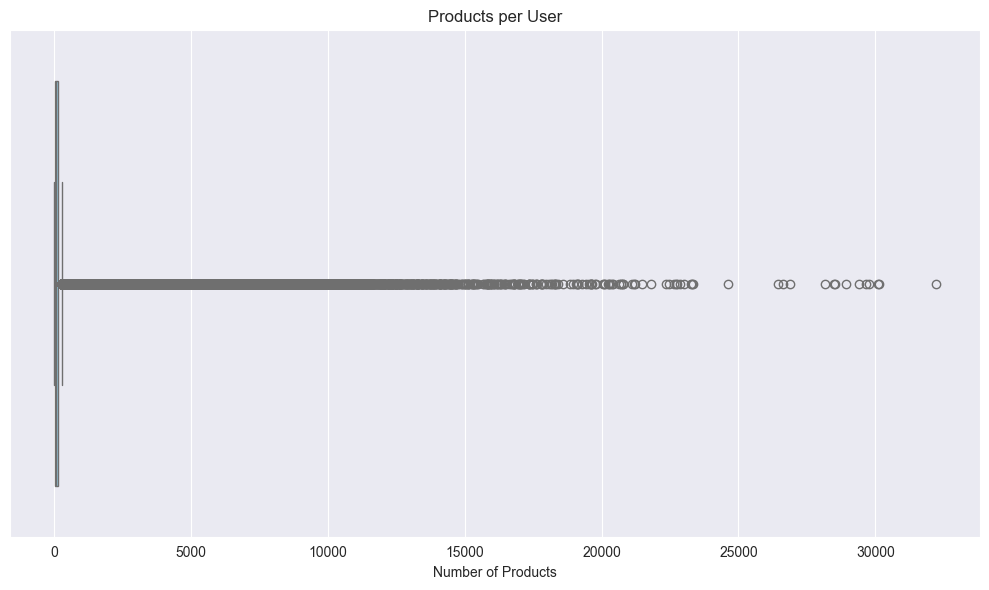

In [40]:
users = df_users.copy()
plt.figure(figsize=(10, 6))
sns.boxplot(x='products', data=users, color='skyblue')
plt.title('Products per User')
plt.xlabel('Number of Products')
plt.tight_layout()
plt.show()

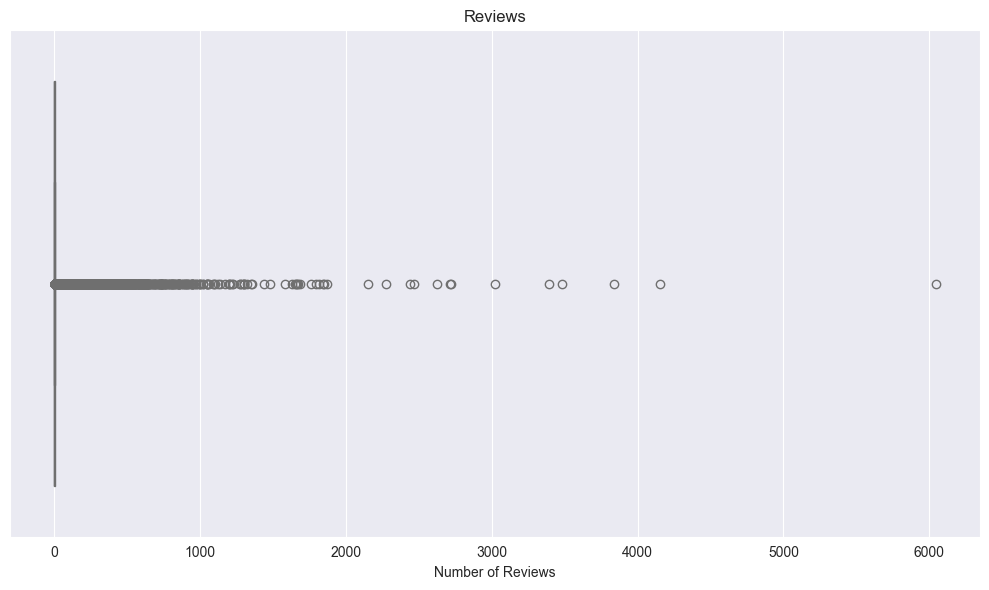

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='reviews', data=users, color='skyblue')
plt.title('Reviews')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [42]:
# Choose the numeric columns to normalize
numeric_cols = ['products', 'reviews']

# Fit scaler and transform
scaler = MinMaxScaler()
df_users[numeric_cols] = scaler.fit_transform(df_users[numeric_cols])

In [43]:
df_users

,user_id,products,reviews
0,7360263,0.011144,0.000000
1,14020781,0.004843,0.000165
2,8762579,0.010213,0.000662
3,4820647,0.005463,0.000662
4,5167327,0.003042,0.000331
...,...,...,...
14306059,5047430,0.000186,0.000000
14306060,5048153,0.000000,0.000000
14306061,5059205,0.000962,0.000000
14306062,5074363,0.000000,0.000000


# User based Colloborative system

In [44]:
recommendations_df.rename(columns={'rating': 'hours_rating'}, inplace=True)


In [45]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,hours_rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


In [46]:
'''#Merge both the dataframes
games_processed_df.set_index('app_id', inplace=True)
recommendations_df = recommendations_df.join(games_processed_df, on='app_id', how='inner')'''


"#Merge both the dataframes\ngames_processed_df.set_index('app_id', inplace=True)\nrecommendations_df = recommendations_df.join(games_processed_df, on='app_id', how='inner')"

In [47]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,hours_rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


In [49]:
def create_cold_start_split(recommendations_df, test_size=0.15, val_size=0.15,
                            timestamp_col='date', cold_start_user_frac=0.01,  seed=42):
    import numpy as np
    np.random.seed(seed)

    # Sort by timestamp if available
    if timestamp_col in recommendations_df.columns:
        recommendations_df = recommendations_df.sort_values(timestamp_col)

    # Identify cold-start users and items
    all_users = recommendations_df['user_id'].unique()
    all_items = recommendations_df['app_id'].unique()

    n_cold_users = int(len(all_users) * cold_start_user_frac)


    cold_users = np.random.choice(all_users, size=n_cold_users, replace=False)


    # Cold-start test data
    cold_user_df = recommendations_df[recommendations_df['user_id'].isin(cold_users)]


    # Remove cold users/items from the remaining dataset
    warm_df = recommendations_df[
        ~recommendations_df['user_id'].isin(cold_users)
    ]

    # Now split warm_df by user chronologically
    user_groups = warm_df.groupby('user_id')

    train_data = []
    val_data = []
    test_data = []

    for user_id, user_data in user_groups:
        n = len(user_data)
        if n < 3:
            continue

        n_test = max(1, int(n * test_size))
        n_val = max(1, int(n * val_size))

        user_train = user_data.iloc[:-n_test-n_val]
        user_val = user_data.iloc[-n_test-n_val:-n_test]
        user_test = user_data.iloc[-n_test:]

        train_data.append(user_train)
        val_data.append(user_val)
        test_data.append(user_test)

    train_df = pd.concat(train_data)
    val_df = pd.concat(val_data)
    test_df = pd.concat(test_data)

    return train_df, val_df, test_df, cold_user_df


train_df, val_df, test_df, cold_user_df = create_cold_start_split(recommendations_df)

print(f"Train Set: {len(train_df)} Recommendations")
print(f"Validation Set: {len(val_df)} Recommendations")
print(f"Test Set: {len(test_df)} Recommendations")
print(f"Cold-Start Test Set: {len(cold_user_df)} Users")

Train Set: 77464 Recommendations
Validation Set: 35794 Recommendations
Test Set: 35794 Recommendations
Cold-Start Test Set: 10446 Users


In [147]:
'''
Randomgrid Search has been tried, However it is not efficient i reckon. So, I am just leaving it here for showcase purpose
'''

import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator
from collections import defaultdict
from scipy.sparse import coo_matrix


# — your existing encoding & filtering —
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_df['user_idx'] = user_enc.fit_transform(train_df['user_id'])
train_df['item_idx'] = item_enc.fit_transform(train_df['app_id'])

test_df = test_df[test_df['user_id'].isin(user_enc.classes_)]
test_df = test_df[test_df['app_id'].isin(item_enc.classes_)]
test_df['user_idx'] = user_enc.transform(test_df['user_id'])
test_df['item_idx'] = item_enc.transform(test_df['app_id'])

#
N = 5

train_matrix = coo_matrix(
    (train_df['is_recommended'], (train_df['user_idx'], train_df['item_idx']))
).tocsr()

# build a mapping of true test items per user
user_true_items = defaultdict(set)
for row in val_df.itertuples():
    user_true_items[row.user_idx].add(row.item_idx)



# 1) wrap your KNN logic in an sklearn estimator
class KNNRecommender(BaseEstimator):
    def __init__(self, n_neighbors=5, top_n=5, metric='cosine', algorithm='brute'):
        self.n_neighbors = n_neighbors
        self.top_n = top_n
        self.metric = metric
        self.algorithm = algorithm

    def fit(self, X, y=None):
        self.X_ = X
        self.n_users_, _ = X.shape
        self.knn_ = NearestNeighbors(
            n_neighbors=self.n_neighbors,
            metric=self.metric,
            algorithm=self.algorithm
        ).fit(X)
        return self

    def predict(self):
        preds = {}
        for u in range(self.n_users_):
            dists, nbrs = self.knn_.kneighbors(self.X_[u], n_neighbors=self.n_neighbors)
            nbrs = nbrs[0][1:]  # drop self
            scores = self.X_[nbrs].sum(axis=0).A1
            seen = self.X_[u].toarray().ravel() > 0
            scores[seen] = 0
            top_items = np.argsort(scores)[::-1][:self.top_n]
            preds[u] = set(top_items)
        return preds

# 2) a scorer that ignores any cv‑split and always uses your held‑out df_test
def mean_f1_scorer(estimator, X, y=None):
    preds = estimator.predict()
    f1s = []
    for u, true_set in user_true_items.items():
        pred_set = preds.get(u, set())
        tp = len(pred_set & true_set)
        fp = len(pred_set - true_set)
        fn = len(true_set - pred_set)
        prec = tp / (tp + fp + 1e-10)
        rec  = tp / (tp + fn + 1e-10)
        f1s.append(2 * prec * rec / (prec + rec + 1e-10))
    return np.mean(f1s)

# 3) build a “dummy” train/test split using integer indices, not slices
n_users = train_matrix.shape[0]
idxs = np.arange(n_users)
cv_splits = [(idxs, idxs)]

# 4) run RandomizedSearchCV on your KNNRecommender
# expand your search space to include different NN algorithms & distance metrics
param_dist = {
    'n_neighbors': np.arange(5, 50),
    'top_n': [5, 10, 20],                           # you could also tune how many you recommend
    'metric': ['cosine', 'euclidean', 'manhattan'], # different similarity measures
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

search = RandomizedSearchCV(
    estimator=KNNRecommender(),
    param_distributions=param_dist,
    n_iter=20,
    scoring=mean_f1_scorer,
    cv=cv_splits,         # <- now actual integer arrays
    refit=False,
    random_state=42,
    verbose=2
)

# pass a dummy y so that .fit(X, y) signature is satisfied
y_dummy = np.zeros(n_users)
search.fit(train_matrix, y_dummy)

print("🏆 Best n_neighbors:", search.best_params_['n_neighbors'])
print("   Best mean F1   :", search.best_score_)


Fitting 1 folds for each of 20 candidates, totalling 20 fits
[CV] END algorithm=auto, metric=euclidean, n_neighbors=5, top_n=5; total time=  50.6s
[CV] END algorithm=ball_tree, metric=cosine, n_neighbors=29, top_n=20; total time=   0.0s
[CV] END algorithm=brute, metric=manhattan, n_neighbors=34, top_n=5; total time=  53.4s


/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/sklearn/neighbors/_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")


[CV] END algorithm=ball_tree, metric=euclidean, n_neighbors=14, top_n=5; total time=  50.6s
[CV] END algorithm=brute, metric=manhattan, n_neighbors=40, top_n=5; total time=  56.1s
[CV] END algorithm=kd_tree, metric=manhattan, n_neighbors=33, top_n=10; total time=  57.7s
[CV] END algorithm=brute, metric=manhattan, n_neighbors=39, top_n=20; total time=  58.5s
[CV] END algorithm=kd_tree, metric=cosine, n_neighbors=5, top_n=10; total time=   0.0s
[CV] END algorithm=kd_tree, metric=cosine, n_neighbors=42, top_n=5; total time=   0.0s
[CV] END algorithm=auto, metric=manhattan, n_neighbors=5, top_n=10; total time= 1.0min
[CV] END algorithm=ball_tree, metric=euclidean, n_neighbors=31, top_n=20; total time=  49.7s
[CV] END algorithm=kd_tree, metric=cosine, n_neighbors=16, top_n=10; total time=   0.0s
[CV] END algorithm=ball_tree, metric=manhattan, n_neighbors=5, top_n=20; total time=  56.5s
[CV] END algorithm=auto, metric=cosine, n_neighbors=14, top_n=20; total time=  52.8s
[CV] END algorithm=ba

/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/var/folders/rx/ncs_rzhx7jqbk6dmztpztl7m0000gn/T/ipykernel_7993/734903294.py", line 51, in fit
    ).fit(X)
  File "/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimato

In [148]:
# 6) turn the full cv_results_ into a DataFrame
import pandas as pd

# grab the raw results
results = pd.DataFrame(search.cv_results_)

# expand the 'params' dict into its own columns
params_df = pd.DataFrame(results['params'].tolist())

# concatenate
df_results = pd.concat([results, params_df], axis=1)

# select and sort the columns you care about
df_results = df_results[[
    'mean_test_score', 'std_test_score', 'rank_test_score',
    'param_n_neighbors', 'param_top_n', 'param_metric', 'param_algorithm'
]].sort_values('rank_test_score')

print(df_results.head(10))

    mean_test_score  std_test_score  rank_test_score  param_n_neighbors  \
13         0.002161             0.0                1                 14   
17         0.001041             0.0                2                 47   
4          0.000898             0.0                3                 40   
6          0.000878             0.0                4                 39   
10         0.000876             0.0                5                 31   
2          0.000835             0.0                6                 34   
15         0.000825             0.0                7                 33   
12         0.000750             0.0                8                  5   
5          0.000511             0.0                9                 33   
3          0.000465             0.0               10                 14   

    param_top_n param_metric param_algorithm  
13           20       cosine            auto  
17            5    euclidean            auto  
4             5    manhattan     

In [50]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator
from collections import defaultdict
from scipy.sparse import coo_matrix


# — your existing encoding & filtering —
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_df['user_idx'] = user_enc.fit_transform(train_df['user_id'])
train_df['item_idx'] = item_enc.fit_transform(train_df['app_id'])

val_df = val_df[val_df['user_id'].isin(user_enc.classes_)]
val_df = val_df[val_df['app_id'].isin(item_enc.classes_)]
val_df['user_idx'] = user_enc.transform(val_df['user_id'])
val_df['item_idx'] = item_enc.transform(val_df['app_id'])

test_df = test_df[test_df['user_id'].isin(user_enc.classes_)]
test_df = test_df[test_df['app_id'].isin(item_enc.classes_)]
test_df['user_idx'] = user_enc.transform(test_df['user_id'])
test_df['item_idx'] = item_enc.transform(test_df['app_id'])

#
N = 5

train_matrix = coo_matrix(
    (train_df['hours_rating'], (train_df['user_idx'], train_df['item_idx']))
).tocsr()

# build a mapping of true test validation items per user
user_true_items = defaultdict(set)
for row in val_df.itertuples():
    user_true_items[row.user_idx].add(row.item_idx)



# 1) wrap your KNN logic in an sklearn estimator
class KNNRecommender(BaseEstimator):
    def __init__(self, n_neighbors=5, top_n=5, metric='cosine', algorithm='brute', eps=1e-6):
        self.n_neighbors = n_neighbors
        self.top_n      = top_n
        self.metric     = metric
        self.algorithm  = algorithm
        self.eps        = eps

    def fit(self, X, y=None):
        self.X_ = X
        self.n_users_, _ = X.shape
        self.knn_ = NearestNeighbors(
            n_neighbors=self.n_neighbors,
            metric=self.metric,
            algorithm=self.algorithm
        ).fit(X)
        return self

    def predict(self):
        preds = {}
        for u in range(self.n_users_):
            # 1) one kneighbors call
            dists, nbrs = self.knn_.kneighbors(
                self.X_[u], n_neighbors=self.n_neighbors
            )
            dists = dists[0]   # shape (n_neighbors,)
            nbrs  = nbrs[0]    # shape (n_neighbors,)

            # 2) drop the self‑match
            dists = dists[1:]
            nbrs  = nbrs[1:]

            # 3) compute similarity weights
            if self.metric == 'cosine':
                sims = 1.0 - dists
            else:
                sims = 1.0 / (dists + self.eps)

            # 4) pull neighbor rows and weight them
            #    neighbor_matrix: (n_neighbors-1, n_items)
            neighbor_matrix = self.X_[nbrs]
            weighted_matrix = neighbor_matrix.multiply(sims[:, None])

            # 5) aggregate into item scores
            scores = weighted_matrix.sum(axis=0).A1

            # 6) zero out already‑seen items
            seen = self.X_[u].toarray().ravel() > 0
            scores[seen] = 0.0

            # 7) pick top‑N
            top_items = np.argsort(scores)[::-1][:self.top_n]
            preds[u] = set(top_items)

        return preds


# 2) a scorer that ignores any cv‑split and always uses your held‑out df_test
def mean_f1_scorer(estimator, X, y=None):
    preds = estimator.predict()
    f1s = []
    for u, true_set in user_true_items.items():
        pred_set = preds.get(u, set())
        tp = len(pred_set & true_set)
        fp = len(pred_set - true_set)
        fn = len(true_set - pred_set)
        prec = tp / (tp + fp + 1e-10)
        rec  = tp / (tp + fn + 1e-10)
        f1s.append(2 * prec * rec / (prec + rec + 1e-10))
    return np.mean(f1s)

# 3) build a “dummy” train/test split using integer indices, not slices
n_users = train_matrix.shape[0]
idxs = np.arange(n_users)
cv_splits = [(idxs, idxs)]

# 4) run GridSearchCV on your KNNRecommender
# expand your search space to include different NN algorithms & distance metrics
# 1) define your (smaller!) grid of hyper‑parameters
param_grid = {
    'n_neighbors': [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],       # fewer choices to keep runtime reasonable
    'top_n':       [5, 10, 20],
    'metric':      ['cosine', 'euclidean', 'manhattan'],
    'algorithm':   ['brute']              # sparse data → stick with brute
}

grid = GridSearchCV(
    estimator=KNNRecommender(),
    param_grid=param_grid,
    scoring=mean_f1_scorer,
    cv=cv_splits,    # your dummy split
    refit=False,
    verbose=2,
    n_jobs=-1        # parallelize across cores
)

# pass a dummy y so that .fit(X, y) signature is satisfied
y_dummy = np.zeros(n_users)
grid.fit(train_matrix, y_dummy)

print("🏆 Best n_neighbors:", grid.best_params_['n_neighbors'])
print("   Best mean F1   :", grid.best_score_)


Fitting 1 folds for each of 99 candidates, totalling 99 fits
🏆 Best n_neighbors: 100
   Best mean F1   : 0.022411937197344047


In [51]:
import pandas as pd

grid_results = pd.DataFrame(grid.cv_results_)
params_df = pd.DataFrame(grid_results['params'].tolist())
UserBasedGridHyper = pd.concat([grid_results, params_df], axis=1)[[
    'mean_test_score','std_test_score','rank_test_score',
    'param_n_neighbors','param_top_n','param_metric','param_algorithm'
]].sort_values('rank_test_score')

UserBasedGridHyper

,mean_test_score,std_test_score,rank_test_score,param_n_neighbors,param_top_n,param_metric,param_algorithm
63,0.022412,0.0,1,100,5,euclidean,brute
60,0.021175,0.0,2,90,5,euclidean,brute
57,0.020155,0.0,3,80,5,euclidean,brute
30,0.020009,0.0,4,100,5,cosine,brute
27,0.018734,0.0,5,90,5,cosine,brute
...,...,...,...,...,...,...,...
2,0.001715,0.0,95,5,20,cosine,brute
67,0.001657,0.0,96,5,10,manhattan,brute
71,0.001644,0.0,97,10,20,manhattan,brute
35,0.001640,0.0,98,5,20,euclidean,brute


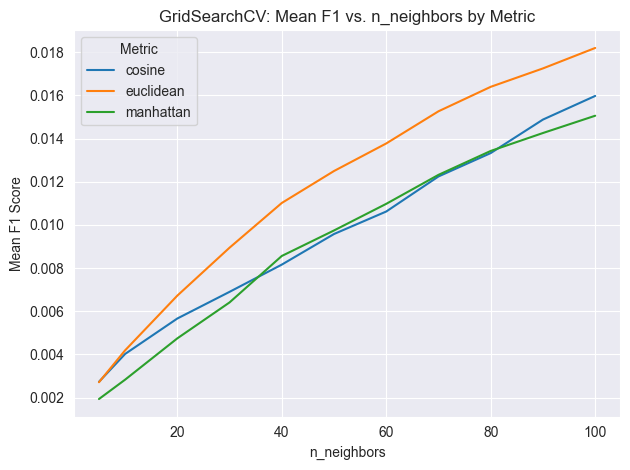

In [52]:

import matplotlib.pyplot as plt


# 2. Pivot so rows are n_neighbors, columns are metrics, values are mean_test_score
pivot = UserBasedGridHyper.pivot_table(
    index='param_n_neighbors',
    columns='param_metric',
    values='mean_test_score',
    aggfunc='mean'
)

# 3. Plot with matplotlib
plt.figure()
for metric in pivot.columns:
    # ensure x-axis is numeric
    x = pivot.index.astype(int)
    y = pivot[metric]
    plt.plot(x, y, label=str(metric))
plt.xlabel('n_neighbors')
plt.ylabel('Mean F1 Score')
plt.title('GridSearchCV: Mean F1 vs. n_neighbors by Metric')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [53]:
best_params = grid.best_params_
print(best_params)
# e.g. → {'n_neighbors': 30, 'top_n': 10, 'metric': 'cosine', 'algorithm': 'brute'}


{'algorithm': 'brute', 'metric': 'euclidean', 'n_neighbors': 100, 'top_n': 5}


In [54]:
train_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 77464 stored elements and shape (34602, 2149)>

In [61]:
# 2) concatenate your DataFrames
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

# 3) (re-)encode user & item indices if needed
#    — if your LabelEncoders were only fit on the train split,
#      refit them on the full recommendation set, or just transform:
# user_enc = LabelEncoder().fit(recommendations_df['user_id'])
# item_enc = LabelEncoder().fit(recommendations_df['app_id'])
train_val_df['user_idx'] = user_enc.transform(train_val_df['user_id'])
train_val_df['item_idx'] = item_enc.transform(train_val_df['app_id'])

# 4) rebuild the sparse matrix
from scipy.sparse import coo_matrix
n_users = train_val_df['user_idx'].max() + 1
n_items = train_val_df['item_idx'].max() + 1
train_val_coo = coo_matrix(
    (train_val_df['hours_rating'],
     (train_val_df['user_idx'], train_val_df['item_idx'])),
    shape=(n_users, n_items)
)
train_val_matrix = train_val_coo.tocsr()


In [62]:
best = grid.best_params_
final_model = KNNRecommender(
    n_neighbors=best['n_neighbors'],
    top_n=best['top_n'],
    metric=best['metric'],
    algorithm=best['algorithm']
).fit(train_val_matrix)


In [63]:
# build a mapping of true test validation items per user
true_test_items = defaultdict(set)
for row in test_df.itertuples():
    true_test_items[row.user_idx].add(row.item_idx)

In [64]:
import numpy as np

def ndcg_at_k(pred_list, true_set, k):
    """
    Compute nDCG@k for one user.
    pred_list : ordered list of recommended item indices
    true_set  : set of ground‐truth relevant item indices
    k         : cutoff
    """
    # DCG
    dcg = 0.0
    for i, item in enumerate(pred_list[:k]):
        if item in true_set:
            dcg += 1.0 / np.log2(i + 2)
    # IDCG (best possible)
    ideal_rel = min(len(true_set), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_rel))
    return dcg / idcg if idcg > 0 else 0.0


In [65]:

preds = final_model.predict()

# Compute Precision@N, Recall@N, F1@N and nDCG@N
precisions, recalls, f1s, ndcgs = [], [], [], []
for u, true_set in true_test_items.items():
    ranked = list(preds.get(u, []))
    pred_set = set(ranked)
    tp = len(pred_set & true_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    # Precision & Recall
    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    precisions.append(prec)
    recalls.append(rec)

    # F1
    f1 = 2 * prec * rec / (prec + rec + 1e-10)
    f1s.append(f1)

    # nDCG
    ndcg = ndcg_at_k(ranked, true_set, k=final_model.top_n)
    ndcgs.append(ndcg)

# Print final metrics
print(f"Final Precision@{final_model.top_n}: {np.mean(precisions):.4f}")
print(f"Final Recall@{final_model.top_n}:    {np.mean(recalls):.4f}")
print(f"Final F1@{final_model.top_n}:        {np.mean(f1s):.4f}")
print(f"Final nDCG@{final_model.top_n}:      {np.mean(ndcgs):.4f}")


Final Precision@5: 0.0195
Final Recall@5:    0.0967
Final F1@5:        0.0324
Final nDCG@5:      0.0570


In [66]:
import joblib

# Assume: final_model is your fitted KNNRecommender,
#         user_enc   is your fitted LabelEncoder for users,
#         item_enc   is your fitted LabelEncoder for items.

# 1) Save to files
joblib.dump(final_model, 'knn_recommender.pkl')
joblib.dump(user_enc,   'user_encoder.pkl')
joblib.dump(item_enc,   'item_encoder.pkl')

print("Models and encoders saved.")


Models and encoders saved.
